TensorFlow version: 2.19.0
Using Colab cache for faster access to the 'asl-alphabet' dataset.
Dataset path: /kaggle/input/asl-alphabet/asl_alphabet_train/asl_alphabet_train
Number of classes: 29
Image size: 96x96
Images per class: 600
Batch size: 128
Loading dataset...
Loaded 10/29 classes
Loaded 20/29 classes
Total images loaded: 17400
Data shape: (17400, 96, 96, 3)
Training samples: 14790
Validation samples: 2610
Creating transfer learning model...
9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 96, 96, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_96             │ (None, 3, 3, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 29)             │         7,453 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,593,373 (9.89 MB)

 Trainable params: 335,389 (1.28 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

Training model...
Epoch 1/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.4040 - loss: 2.1972 - val_accuracy: 0.9257 - val_loss: 0.3092 - learning_rate: 0.0010
Epoch 2/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 138s 1s/step - accuracy: 0.8435 - loss: 0.4943 - val_accuracy: 0.9575 - val_loss: 0.1631 - learning_rate: 0.0010
Epoch 3/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 137s 1s/step - accuracy: 0.8941 - loss: 0.3274 - val_accuracy: 0.9674 - val_loss: 0.1256 - learning_rate: 0.0010
Epoch 4/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 139s 1s/step - accuracy: 0.9159 - loss: 0.2583 - val_accuracy: 0.9682 - val_loss: 0.1055 - learning_rate: 0.0010
Epoch 5/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 140s 1s/step - accuracy: 0.9315 - loss: 0.2012 - val_accuracy: 0.9774 - val_loss: 0.0780 - learning_rate: 0.0010
Epoch 6/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 132s 1s/step - accuracy: 0.9440 - loss: 0.1760 - val_accuracy: 0.9774 - val_loss: 0.0755 - learning_rate: 0.0010
Epoch 7/10
116/116 ━━━━━━━━━━━━━━━━━━━━ 143s 1s/step - accuracy:

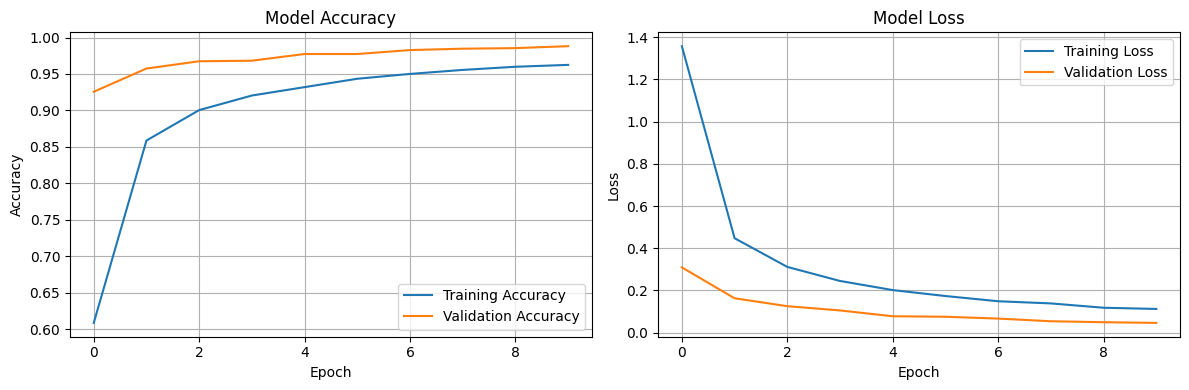

21/21 ━━━━━━━━━━━━━━━━━━━━ 23s 1s/step
Validation accuracy: 0.9881

Classification Report:
              precision    recall  f1-score   support

           A       0.99      1.00      0.99        90
           B       1.00      1.00      1.00        90
           C       1.00      1.00      1.00        90
           D       0.98      1.00      0.99        90
           E       0.99      0.99      0.99        90
           F       0.99      0.99      0.99        90
           G       1.00      1.00      1.00        90
           H       1.00      1.00      1.00        90
           I       0.97      1.00      0.98        90
           J       1.00      1.00      1.00        90
           K       0.99      0.98      0.98        90
           L       1.00      1.00      1.00        90
           M       1.00      0.98      0.99        90
           N       0.98      1.00      0.99        90
           O       1.00      1.00      1.00        90
           P       1.00      1.00      1.00 

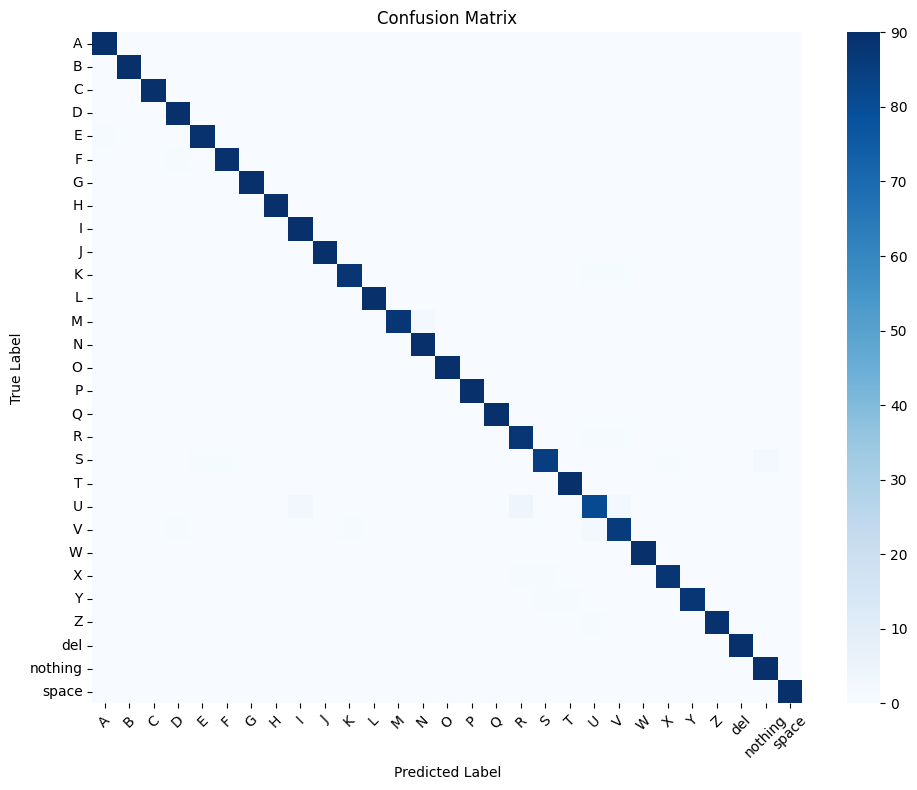

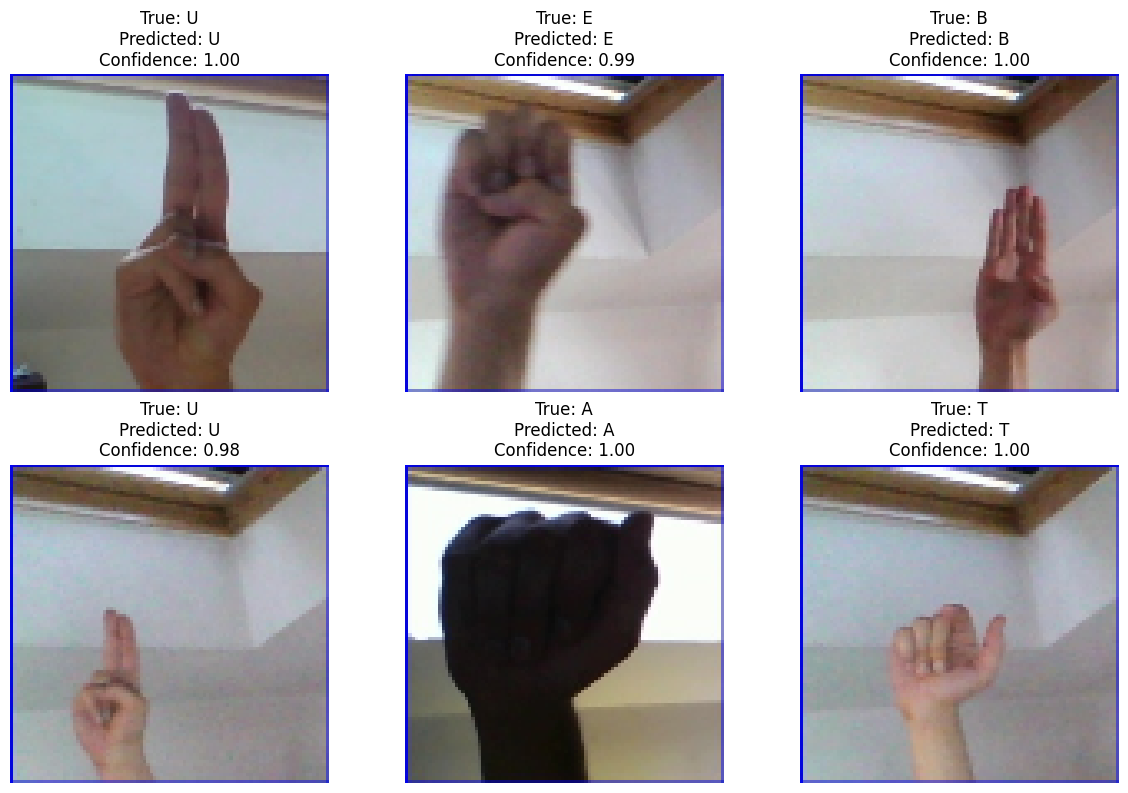

ASL DETECTION PROJECT SUMMARY
Total classes: 29
Training samples: 14790
Validation samples: 2610
Training time: 23.00 minutes
Best validation accuracy: 0.9881
Image size: 96x96
Batch size: 128
Model: Transfer Learning (MobileNetV2)


In [1]:
# American Sign Language Detection System
# Objective: Build a system that can detect ASL input images and classify into 29 classes

import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.applications import MobileNetV2
import cv2
import time
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow version: {tf.__version__}")

# Download Dataset using kagglehub
import kagglehub

path = kagglehub.dataset_download("grassknoted/asl-alphabet")
train_path = os.path.join(path, 'asl_alphabet_train', 'asl_alphabet_train')

print(f"Dataset path: {train_path}")

# Configuration
CLASSES = ['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M',
           'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z',
           'del', 'nothing', 'space']

NUM_CLASSES = 29
IMG_SIZE = 96
BATCH_SIZE = 128
IMAGES_PER_CLASS = 600

class_to_idx = {c: i for i, c in enumerate(CLASSES)}

print(f"Number of classes: {NUM_CLASSES}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Images per class: {IMAGES_PER_CLASS}")
print(f"Batch size: {BATCH_SIZE}")

def load_class_images(folder_path, class_name, max_images, img_size):
    images = []
    labels = []

    if not os.path.exists(folder_path):
        return images, labels

    files = os.listdir(folder_path)
    np.random.shuffle(files)

    count = 0
    for filename in files:
        if count >= max_images:
            break

        if filename.endswith(('.png', '.jpg', '.jpeg')):
            try:
                img_path = os.path.join(folder_path, filename)
                img = cv2.imread(img_path)
                img = cv2.resize(img, (img_size, img_size))
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                img = img / 255.0

                images.append(img)
                labels.append(class_to_idx[class_name])
                count += 1
            except:
                continue

    return images, labels

print("Loading dataset...")
X_data = []
y_data = []

for i, class_name in enumerate(CLASSES):
    class_folder = os.path.join(train_path, class_name)
    images, labels = load_class_images(class_folder, class_name, IMAGES_PER_CLASS, IMG_SIZE)
    X_data.extend(images)
    y_data.extend(labels)

    if (i + 1) % 10 == 0:
        print(f"Loaded {i + 1}/{NUM_CLASSES} classes")

X_data = np.array(X_data, dtype=np.float32)
y_data = np.array(y_data)

print(f"Total images loaded: {len(X_data)}")
print(f"Data shape: {X_data.shape}")

# Train/Validation Split
y_categorical = to_categorical(y_data, NUM_CLASSES)

X_train, X_val, y_train, y_val = train_test_split(
    X_data, y_categorical, test_size=0.15, random_state=42, stratify=y_data
)

print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")

del X_data, y_data

# Build Model
print("Creating transfer learning model...")

base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

model = keras.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    layers.Rescaling(scale=2.0, offset=-1),
    base_model,
    layers.GlobalAveragePooling2D(),
    layers.Dropout(0.3),
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Training
EPOCHS = 10

callbacks = [
    keras.callbacks.EarlyStopping(
        patience=3,
        restore_best_weights=True,
        monitor='val_accuracy',
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        factor=0.2,
        patience=2,
        min_lr=1e-6,
        monitor='val_accuracy',
        verbose=1
    )
]

print("Training model...")
start_time = time.time()

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=callbacks,
    verbose=1
)

training_time = (time.time() - start_time) / 60
print(f"Training completed in {training_time:.2f} minutes")

best_accuracy = max(history.history['val_accuracy'])
print(f"Best validation accuracy: {best_accuracy:.4f}")

# Visualization
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'], label='Training Accuracy')
ax1.plot(history.history['val_accuracy'], label='Validation Accuracy')
ax1.set_title('Model Accuracy')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history.history['loss'], label='Training Loss')
ax2.plot(history.history['val_loss'], label='Validation Loss')
ax2.set_title('Model Loss')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# Evaluation
y_pred = model.predict(X_val, batch_size=BATCH_SIZE)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_val, axis=1)

accuracy = np.mean(y_pred_classes == y_true_classes)
print(f"Validation accuracy: {accuracy:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_classes, y_pred_classes, target_names=CLASSES, zero_division=0))

# Confusion Matrix
cm = confusion_matrix(y_true_classes, y_pred_classes)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=False, cmap='Blues', xticklabels=CLASSES, yticklabels=CLASSES)
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Sample Predictions
num_samples = 6
sample_indices = np.random.choice(len(X_val), num_samples, replace=False)

fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.ravel()

for i, idx in enumerate(sample_indices):
    img = X_val[idx]
    true_label = CLASSES[y_true_classes[idx]]
    pred_label = CLASSES[y_pred_classes[idx]]
    confidence = y_pred[idx][y_pred_classes[idx]]

    axes[i].imshow(img)
    axes[i].set_title(f'True: {true_label}\nPredicted: {pred_label}\nConfidence: {confidence:.2f}')
    axes[i].axis('off')

plt.tight_layout()
plt.show()

# Summary
print("=" * 60)
print("ASL DETECTION PROJECT SUMMARY")
print("=" * 60)
print(f"Total classes: {NUM_CLASSES}")
print(f"Training samples: {len(X_train)}")
print(f"Validation samples: {len(X_val)}")
print(f"Training time: {training_time:.2f} minutes")
print(f"Best validation accuracy: {best_accuracy:.4f}")
print(f"Image size: {IMG_SIZE}x{IMG_SIZE}")
print(f"Batch size: {BATCH_SIZE}")
print(f"Model: Transfer Learning (MobileNetV2)")
print("=" * 60)